In [2]:
!pip install seaborn

[OK] Đã kết nối với module src.graph.graph_builder

   KẾT QUẢ THỐNG KÊ ĐỒ THỊ
[*] Số lượng Node (Quận/Huyện): 22
[*] Số lượng Edge (Liên kết):    54
[*] Mật độ đồ thị (Density):    0.2338
[*] Bậc trung bình:              4.91
[*] Đồ thị liên thông toàn bộ:  CÓ

------------------------------
[Xong] Đã xuất file đồ thị: E:\project_Graph\GM_DengueFever\data\processed\hcm_dengue_graph.graphml
[Xong] Đã lưu hình ảnh:     E:\project_Graph\GM_DengueFever\outputs\graph_spatial_analysis.png
------------------------------


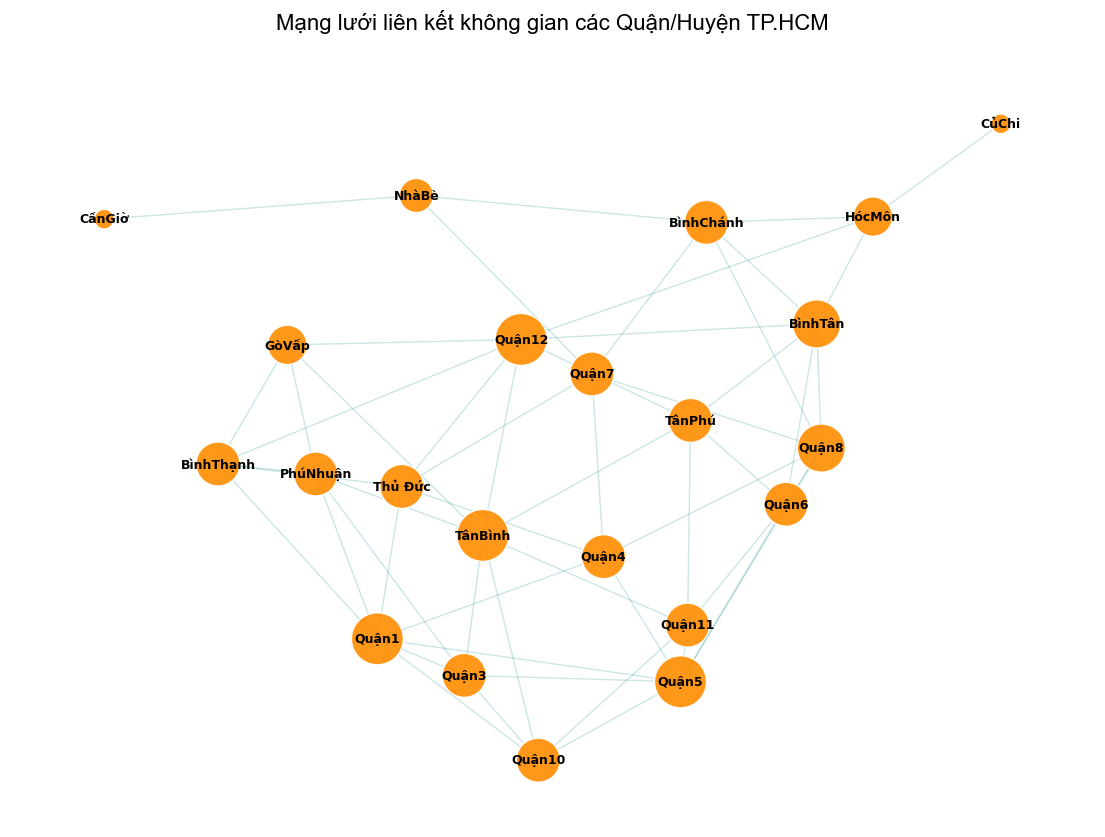


--- Đang trích xuất dữ liệu Nodes & Edges vào data/processed ---
[Xong] Đã lưu Nodes: E:\project_Graph\GM_DengueFever\data\processed\graph_nodes.csv
[Xong] Đã lưu Edges: E:\project_Graph\GM_DengueFever\data\processed\graph_edges.csv


In [8]:
# =========================================================
# PROJECT: Dengue Fever Graph Modeling - TP.HCM
# STEP 02: Graph Construction & Network Analysis
# Role: Member A (Lead) & Member B (Support)
# =========================================================

import sys
import os
import networkx as nx
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- PHẦN 0: XỬ LÝ ĐƯỜNG DẪN HỆ THỐNG ---
# Tự động xác định thư mục gốc GM_DengueFever
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.append(project_root)

# Import hàm build_graph sau khi đã cấu hình sys.path
try:
    from src.graph.graph_builder import build_graph
    print("[OK] Đã kết nối với module src.graph.graph_builder")
except ImportError:
    print("[Lỗi] Không tìm thấy module src. Vui lòng kiểm tra file __init__.py trong các thư mục src và graph.")

# --- PHẦN 1: CẤU HÌNH ĐƯỜNG DẪN DỮ LIỆU ---
DATA_RAW = os.path.join(project_root, "data", "raw")
DATA_PROCESSED = os.path.join(project_root, "data", "processed")
OUTPUTS = os.path.join(project_root, "outputs")

os.makedirs(OUTPUTS, exist_ok=True)

# --- PHẦN 2: XÂY DỰNG ĐỒ THỊ ---
adj_path = os.path.join(DATA_PROCESSED, "adjacency_matrix.csv")
traffic_path = os.path.join(DATA_PROCESSED, "traffic_index.csv")

if not os.path.exists(adj_path):
    # Gợi ý cho Trưởng nhóm cách fix nếu thiếu file
    print(f"LỖI: Không tìm thấy file ma trận tại {adj_path}")
    print("Mẹo: Hãy chạy 'python src/graph/build_adjacency.py' trong Anaconda Prompt trước!")
else:
    # Xây dựng đồ thị
    G = build_graph(adj_path, traffic_path if os.path.exists(traffic_path) else None)

    # --- PHẦN 3: THỐNG KÊ CƠ BẢN ---
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)
    degrees = dict(G.degree())
    avg_degree = sum(degrees.values()) / n_nodes

    print("\n" + "="*30)
    print("   KẾT QUẢ THỐNG KÊ ĐỒ THỊ")
    print("="*30)
    print(f"[*] Số lượng Node (Quận/Huyện): {n_nodes}")
    print(f"[*] Số lượng Edge (Liên kết):    {n_edges}")
    print(f"[*] Mật độ đồ thị (Density):    {density:.4f}")
    print(f"[*] Bậc trung bình:              {avg_degree:.2f}")

    # --- PHẦN 4: KIỂM TRA TÍNH LIÊN THÔNG ---
    is_connected = nx.is_connected(G)
    print(f"[*] Đồ thị liên thông toàn bộ:  {'CÓ' if is_connected else 'KHÔNG'}")

    if not is_connected:
        components = list(nx.connected_components(G))
        print(f"    -> Cảnh báo: Đồ thị bị rời rạc thành {len(components)} cụm.")
        # Thường Cần Giờ sẽ bị rời ra nếu không có cầu/phà nối trong ma trận
        for i, c in enumerate(components):
            print(f"       + Cụm {i+1}: {list(c)[:3]}... ({len(c)} nodes)")

    # --- PHẦN 5: TRỰC QUAN HÓA (SPRING LAYOUT) ---
    plt.figure(figsize=(14, 10))
    
    # Sử dụng font hỗ trợ tiếng Việt (Arial hoặc Tahoma)
    plt.rcParams['font.family'] = 'Arial' 
    
    pos = nx.spring_layout(G, k=0.8, seed=42)

    # Vẽ cạnh: Trọng số càng cao (traffic nhiều) thì nét càng đậm
    edge_weights = [G[u][v].get('weight', 1.0) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=edge_weights, edge_color='teal')

    # Vẽ node: Node càng nhiều liên kết (Hub) thì càng to
    node_sizes = [v * 200 for v in degrees.values()]
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                           node_color='darkorange', alpha=0.9,
                           edgecolors='white', linewidths=1)

    # Vẽ nhãn: Hiển thị tên Quận/Huyện
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    plt.title("Mạng lưới liên kết không gian các Quận/Huyện TP.HCM", fontsize=16, pad=20)
    plt.axis('off')

    # --- PHẦN 6: LƯU KẾT QUẢ & BÀN GIAO ---
    # 1. Lưu ảnh báo cáo
    output_img = os.path.join(OUTPUTS, "graph_spatial_analysis.png")
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    
    # 2. Lưu file GraphML cho Thành viên C (Phụng) làm GNN
    graph_export_path = os.path.join(DATA_PROCESSED, "hcm_dengue_graph.graphml")
    nx.write_graphml(G, graph_export_path)
    
    print("\n" + "-"*30)
    print(f"[Xong] Đã xuất file đồ thị: {graph_export_path}")
    print(f"[Xong] Đã lưu hình ảnh:     {output_img}")
    print("-"*30)

    plt.show()

    # --- PHẦN 7: XUẤT DỮ LIỆU BẢNG VÀO DATA/PROCESSED ---

print("\n--- Đang trích xuất dữ liệu Nodes & Edges vào data/processed ---")

# 1. Trích xuất danh sách Nodes (kèm theo Degree - Bậc của quận)
nodes_list = []
degrees = dict(G.degree())

for node, attrs in G.nodes(data=True):
    node_data = {
        'district': node,
        'degree': degrees.get(node, 0)
    }
    node_data.update(attrs)  # Gán thêm các thuộc tính khác nếu có
    nodes_list.append(node_data)

nodes_df = pd.DataFrame(nodes_list)

# 2. Trích xuất danh sách Edges (Nguồn - Đích - Trọng số)
edges_list = []
for u, v, attrs in G.edges(data=True):
    edges_list.append({
        'source': u,
        'target': v,
        'weight': attrs.get('weight', 1.0)
    })

edges_df = pd.DataFrame(edges_list)

# 3. Định nghĩa đường dẫn và Lưu file
nodes_processed_path = os.path.join(DATA_PROCESSED, "graph_nodes.csv")
edges_processed_path = os.path.join(DATA_PROCESSED, "graph_edges.csv")

# Sử dụng utf-8-sig để tránh lỗi font tiếng Việt khi mở bằng Excel
nodes_df.to_csv(nodes_processed_path, index=False, encoding='utf-8-sig')
edges_df.to_csv(edges_processed_path, index=False, encoding='utf-8-sig')

print(f"[Xong] Đã lưu Nodes: {nodes_processed_path}")
print(f"[Xong] Đã lưu Edges: {edges_processed_path}")